In [18]:
#pip install pandas ipywidgets
#!pip install --upgrade jupyterlab
#!pip install --upgrade ipywidgets
#!jupyter labextension update --all
#!jupyter labextension install @jupyter-widgets/jupyterlab-manager@2.0.0
#pip install tabulate
#pip install dash

# Summary

## Row

In [23]:
import pandas as pd
import numpy as np
# Abrimos la base de datos
#df = pd.read_csv(r'C:\Users\dan04\Box\Sesame Workshop PED process evaluation\07_Questionnaires & Data\04 Endline\01 Raw Data Backup\Endline Encuesta Juega Todos los Días (Docentes_directivos)_WIDE.csv')
df = pd.read_csv(r'C:\Users\dan04\Box\Climate Shocks\07_Questionnaires & Data\02 Baseline\01 Raw Data Backup\Climate Shocks Levantamiento_WIDE.csv')
#df = pd.read_csv(r'C:\Users\laura\Downloads\Climate Shocks Levantamiento_WIDE.csv')

# Todas las variables las cambiamos a minúsculas
df.columns = df.columns.str.lower()

In [25]:
# Definimos el total de entrevistas que queremos tener
total_goal = 200

# Definimos la variable para contar el número de entrevistas válidas
valid_interviews = df['consent'].sum()

# Calculamos el porcentaje de entrevistas terminadas
percentage_finished = (valid_interviews / total_goal) * 100

# Formato del porcentaje
formatted_percentage_finished = f"{percentage_finished:.2f}%"

# Si %>50 se presenta de color verde, si %<50 es naranja
if percentage_finished > 50:
    color = "success"
else:
    color = "warning"

In [27]:
#| content: valuebox
#| title: "Completed interviews"
dict(
  icon = "bullseye",
  color = color,
  value = formatted_percentage_finished
)

{'icon': 'bullseye', 'color': 'warning', 'value': '42.50%'}

In [29]:
import pandas as pd

# Convertir la variable que indica la fecha a "datetime"
df['submissiondate']=pd.to_datetime(df['submissiondate'], format='%d/%m/%Y, %H:%M:%S')

# Buscamos la fecha en la que se levantó la primer entrevista
earliest_date = df['submissiondate'].min()

# Fecha de hoy
today = pd.Timestamp.now()

# Calculamos el número de días desde la primera entrevista
days_since_start = (today - earliest_date).days

In [31]:
#| content: valuebox
#| title: "Number of Days since Launch"
dict(
  icon = "calendar-week",
  color = "light",
  value = days_since_start
)

{'icon': 'calendar-week', 'color': 'light', 'value': 122}

In [33]:
# Calculamos el porcentaje de missings de ID's
total_values = df.size

# Definimos la variable de ID's
column_name = 'devicephonenum'

missing_values = df[column_name].isnull().sum()
missing_percentage = (missing_values / total_values) * 100

In [35]:
# Si %>50 se presenta de color naranja, si %<50 es verde

if missing_percentage > 20:
    color = "warning"
else:
    color = "success"

In [37]:
formatted_missing_percentage = f"{missing_percentage:.2f}%"

In [39]:
#| content: valuebox
#| title: "Missing ID's"
dict(
  icon = "exclamation-triangle",
  color = color,
  value = formatted_missing_percentage
)

{'icon': 'exclamation-triangle', 'color': 'success', 'value': '0.04%'}

## Row

In [42]:
#Convertir las fechas
df['submissiondate'] = pd.to_datetime(df['submissiondate'])
df['fecha_solo'] = df['submissiondate'].dt.date

# Agrupar por fecha y contar el número de IDs
conteo_por_fecha = df.groupby('fecha_solo').size()

# Calcular el promedio de entrevistas por día
average_interviews_per_day = conteo_por_fecha.mean()

# Redondear el número de entrevistas
rounded_average_day = round(average_interviews_per_day, 2)

In [44]:
#| content: valuebox
#| title: "Average Number of Interviews per Day"
dict(
  icon = "clipboard",
  color = "light",
  value = rounded_average_day
)

{'icon': 'clipboard', 'color': 'light', 'value': 7.23}

In [46]:
#Contar el número de entrevistadores
unique_enumerators = df['enumid'].nunique()

In [48]:
#| content: valuebox
#| title: "Number of Enumerators"
dict(
  icon = "person",
  color = "light",
  value = unique_enumerators
)

{'icon': 'person', 'color': 'light', 'value': 11}

In [50]:
# Contar el número de entrevistas por entrevistador
interviews_per_interviewer = df.groupby('enumid').size().reset_index(name='interviews_count')

# Calcular el promedio de entrevistas por entrevistador
average_interviews_per_interviewer = interviews_per_interviewer['interviews_count'].mean()

# Redondear el número de entrevistas
rounded_average = round(average_interviews_per_interviewer, 2)


In [52]:
#| content: valuebox
#| title: "Average Interviews per Enumerator"
dict(
  icon = "graph-up",
  color = "light",
  value = rounded_average
)

{'icon': 'graph-up', 'color': 'light', 'value': 8.55}

## Row 

In [55]:
from datetime import datetime

# Obtener la fecha actual
today = datetime.now().strftime('%B %d, %Y')  # Formato: Mes día, Año (e.g., August 22, 2024)

# Crear el texto
last_updated_text = f"Last update: {today}"

# Mostrar el texto
print(last_updated_text)

Last update: September 09, 2024


# Survey Progress

## Row {height=40%}

In [59]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

In [61]:
mapping = {1: 'Consent', 0: 'No Consent'}

df['consent'] = df['consent'].map(mapping)

In [63]:
summary = df.groupby('consent')['key'].nunique().reset_index()
summary.columns = ['Consent Status', 'Unique ID Count']

#| tittle: Consent
summary

,Consent Status,Unique ID Count
0,Consent,85
1,No Consent,3


In [65]:
summary = df.groupby('consent').agg(
    Unique_ID_Count=('key','count'),
    recording_consent=('recording_consent','count'),
    gps_consent = ('gps_consent','count')
    
).reset_index()

summary.columns = ['Consent Status', 'Number of Unique IDs', 'Recording Consent', 'GPS Consent']

summary


,Consent Status,Number of Unique IDs,Recording Consent,GPS Consent
0,Consent,85,79,79
1,No Consent,3,0,0


## Row {height=60%}

In [68]:
import pandas as pd
import matplotlib.pyplot as plt

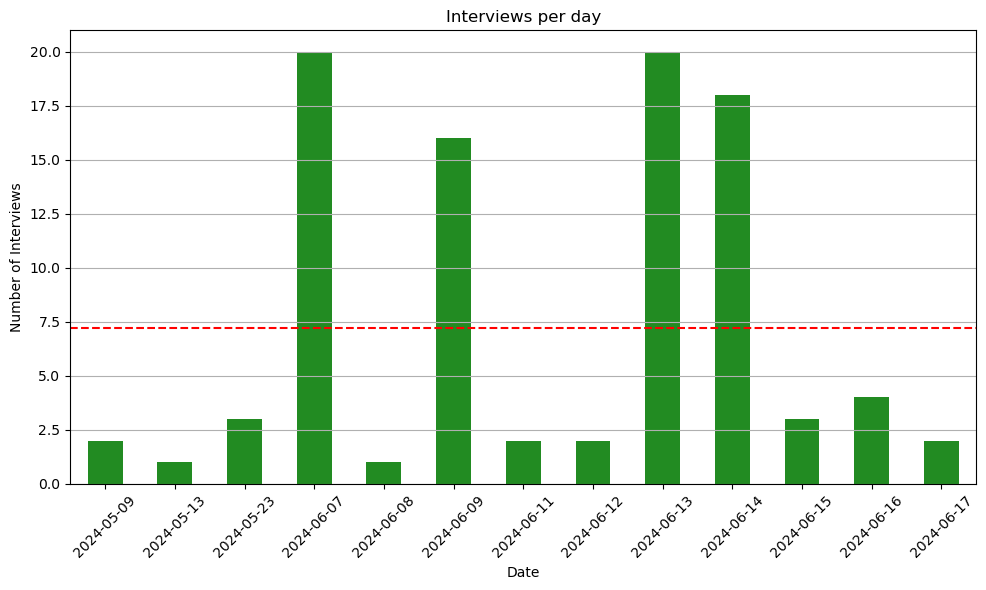

In [69]:
#Convertir las fechas
df['submissiondate'] = pd.to_datetime(df['submissiondate'])
df['fecha_solo'] = df['submissiondate'].dt.date

# Agrupar por fecha y contar el número de IDs
conteo_por_fecha = df.groupby('fecha_solo').size()

# Calcular el promedio de entrevistas por día
average_interviews_per_day = conteo_por_fecha.mean()

# Crear la gráfica de barras
plt.figure(figsize=(10, 6))
conteo_por_fecha.plot(kind='bar', color='forestgreen')

# Añadir una línea horizontal con el promedio
plt.axhline(y=average_interviews_per_day, color='red', linestyle='--', label=f'Average: {average_interviews_per_day:.2f}')

# Añadir títulos y etiquetas
plt.title('Interviews per day')
plt.xlabel('Date')
plt.ylabel('Number of Interviews')
plt.xticks(rotation=45)
plt.grid(axis='y')

# Mostrar la gráfica
plt.tight_layout()
plt.show()


# Duplicates

## Row {height = 20%}

In [74]:
# Encontrar los duplicados 
num_duplicates = df.duplicated(subset='deviceid', keep=False).sum()


In [76]:
#| content: valuebox
#| title: "Total Number of Duplicates"
dict(
  icon = "file-medical",
  color = "light",
  value = num_duplicates
)

{'icon': 'file-medical', 'color': 'light', 'value': 91}

## Row {height = 80%}

In [79]:
# Crear una columna auxiliar para marcar duplicados
df['aux_dups'] = df.duplicated(subset=['deviceid'], keep=False).astype(int)

# Filtrar el DataFrame para mostrar solo las filas donde 'aux_dups' no es 0
df_duplicados = df[df['aux_dups'] != 0]

# Ajustar la configuración para mostrar todas las filas
pd.set_option('display.max_rows', None)  # Cambiar para mostrar todas las filas

# Seleccionar solo las columnas 'caseid' y 'fecha'
result = df_duplicados[['deviceid','key', 'submissiondate']]

result

,deviceid,key,submissiondate
0,(web),uuid:5fab1eec-4e2c-44f1-a9e4-f3a0315db729,2024-05-09 14:55:53
1,(web),uuid:edbae6fd-d200-4e40-ae4a-cfad7329b35d,2024-05-09 16:18:54
2,(web),uuid:6f1ec5fe-1c0e-4aa9-b10d-6e730af18782,2024-05-13 17:54:44
4,CE65594B-BB21-4C67-B51D-285E5DECA674,uuid:0a45d049-a536-4f8e-95fe-62873755ba30,2024-05-23 17:18:32
5,99c76a70f497bed3,uuid:2f8301f2-a247-4c7c-80e5-fcdb3557ee8f,2024-05-23 17:24:11
6,99c76a70f497bed3,uuid:38ef19d7-c8c2-4fa5-8d6e-3fc0d82a3580,2024-06-07 09:19:47
7,CE65594B-BB21-4C67-B51D-285E5DECA674,uuid:4c0a94cb-dc02-41e7-b90f-238b6982dd62,2024-06-07 12:29:30
8,99c76a70f497bed3,uuid:5599c90f-fdba-4f55-9b2f-85d6d913b759,2024-06-07 18:01:38
9,99c76a70f497bed3,uuid:92f2026a-ec8f-4ffa-97ed-0361ef9948fc,2024-06-07 18:01:39
10,862b4275400f786f,uuid:880190e1-62d4-4da7-8c92-0fdb2b4597ef,2024-06-07 18:03:34


# Enumerator Statistics

## Row

In [83]:
# import plotly.express as px

# Filtrar los datos para cada enumerador y crear gráficos y resúmenes enumerators = df['enumid'].unique()

# Convertir la columna 'consent' a numérico, forzando errores a NaN
#df['consent'] = pd.to_numeric(df['consent'], errors='coerce')

#def generate_plots_for_enumerator(enumerator):
    # Filtrar datos para el enumerador específico
    #data = df[df['enumid'] == enumerator]

    # 1. Calcular el porcentaje de consentimiento
    #consent_percentage = data['consent'].mean() * 100

    # 2. Calcular el número total de entrevistas
    #total_interviews = data['key'].nunique()

    # 3. Gráfica de entrevistas por día
    #interviews_per_day = data.groupby('submissiondate').size().reset_index(name='count')
    #fig = px.bar(interviews_per_day, x='submissiondate', y='count', title=f'Entrevistas por Día para {enumerator}', labels={'count': 'Number of Interviews'})

    #return consent_percentage, total_interviews, fig
# Crear un diccionario para almacenar los resultados
#results = {enumerator: generate_plots_for_enumerator(enumerator) for enumerator in enumerators}

In [85]:
#import plotly.io as pio

# Mostrar los resultados en pestañas
#for enumerator, (consent_percentage, total_interviews, fig) in results.items():
 #   print(f"### {enumerator}")

  #  print(f"- **Porcentaje de Consentimiento:** {consent_percentage:.2f}%")
   # print(f"- **Número Total de Entrevistas:** {total_interviews}")

    # Mostrar la gráfica
    #pio.show(fig)


## Row {height = 40%}

In [98]:
# Convertir la columna 'consent' a numérico
df['consent'] = pd.to_numeric(df['consent'],errors='coerce')
df = df[df['consent'].notna()]

#Crear la tabla
summary = df.groupby('enumid').agg(
    total_persons=('key','size'),
    consented_persons=('consent','sum'),
    
).reset_index()

# Calcular el porcentaje de consentimiento
summary['consent_percentage'] = (summary['consented_persons'] / summary['total_persons']) * 100

# Cambiar los nombres de las columnas
summary.rename(columns={
    'enumid': 'Enumerator ID',
    'total_persons': 'Total Interviews',
    'consented_persons': 'Consented Interviews',
    'consent_percentage': 'Consent Percentage'
}, inplace=True)

# Restablecer el índice para convertirlo en DataFrame
# Verificar el resultado
summary[['Enumerator ID', 'Total Interviews','Consented Interviews','Consent Percentage']]



,Enumerator ID,Total Interviews,Consented Interviews,Consent Percentage


## Row {height=60%}

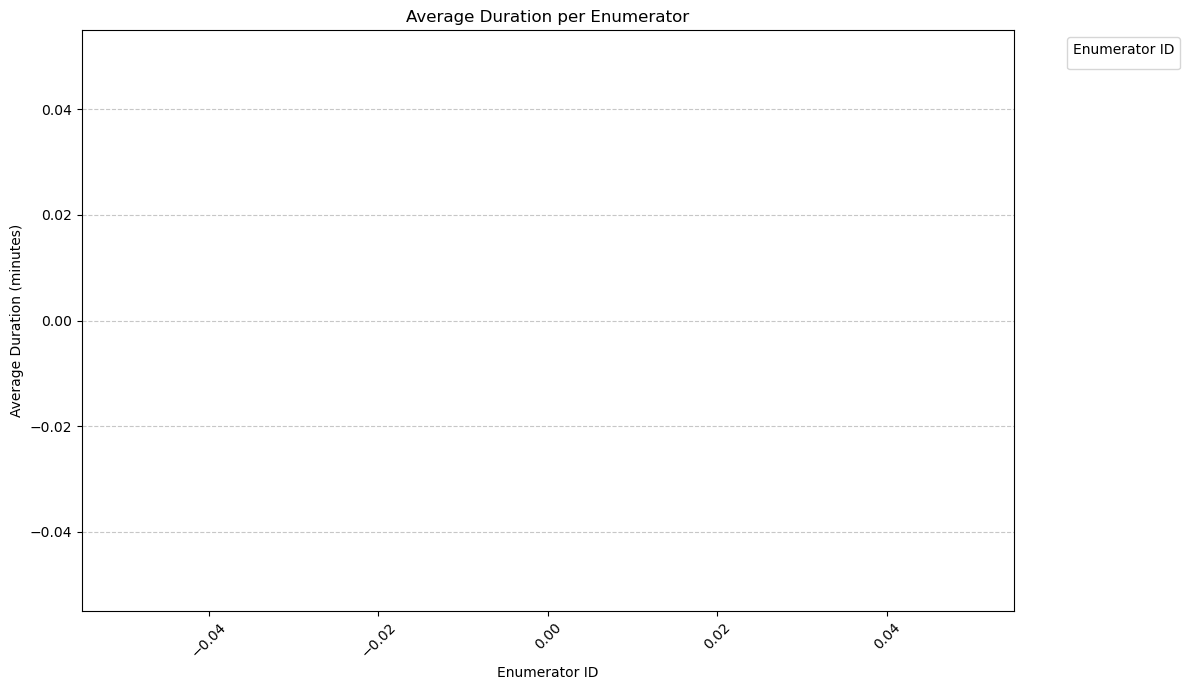

In [101]:
import matplotlib.pyplot as plt
import numpy as np
   
# Convertir la duración de segundos a minutos
df['duration_mins'] = df['duration'] / 60

# Calcular el tiempo promedio de duración por entrevistador
average_duration = df.groupby('enumid').agg(
    avg_duration=('duration_mins', 'mean')
).reset_index()

# Calcular el promedio general de duración
overall_avg_duration = average_duration['avg_duration'].mean()

# Obtener una lista de colores para cada entrevistador
num_enumerators = len(average_duration)
colors = plt.get_cmap('tab20', num_enumerators)

# Crear la gráfica
plt.figure(figsize=(12, 7))

# Asignar un color diferente para cada barra
bars = plt.bar(average_duration['enumid'].astype(str), average_duration['avg_duration'],
               color=[colors(i / num_enumerators) for i in range(num_enumerators)])

# Añadir una línea horizontal que muestre el promedio general
plt.axhline(y=overall_avg_duration, color='r', linestyle='--', label=f'Overall Average ({overall_avg_duration:.2f} mins)')

# Añadir etiquetas y título
plt.xlabel('Enumerator ID')
plt.ylabel('Average Duration (minutes)')
plt.title('Average Duration per Enumerator')
plt.xticks(rotation=45) 
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Añadir una leyenda
plt.legend(bars, average_duration['enumid'].astype(str), title='Enumerator ID', bbox_to_anchor=(1.05, 1), loc='upper left')

# Ajustar el diseño
plt.tight_layout()

# Mostrar la gráfica
plt.show()

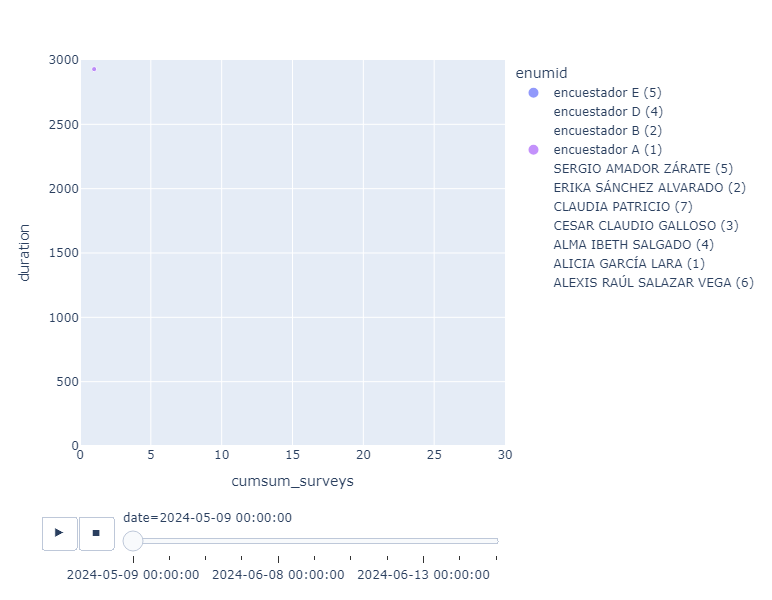

In [110]:
#import pandas as pd
import datetime
# package for gapminder example
import plotly.express as px

# Load data base
#df = pd.read_csv(r'C:\Users\laura\Box\Sesame Workshop PED process evaluation\07_Questionnaires & Data\04 Endline\01 Raw Data Backup\Endline Encuesta Juega Todos los Días (Docentes_directivos)_WIDE.csv')
#df = pd.read_csv(r'C:\Users\laura\Downloads\Climate Shocks Levantamiento_WIDE.csv')
df = pd.read_csv(r'C:\Users\dan04\Box\Climate Shocks\07_Questionnaires & Data\02 Baseline\01 Raw Data Backup\Climate Shocks Levantamiento_WIDE.csv')

# lower case variable names
df.columns = df.columns.str.lower()
df["date_str"] = df["endtime"].str[:9].str.replace(',', '')
df["date"] = pd.to_datetime(df["date_str"],format='%d/%m/%Y')

df = df[['date','supervisor_id','enumid','instanceid','duration']]

# computing cumulative average duration of surveys by enumerator
#df1 = df
#df1 = df1.sort_values(['supervisor_id','enumid','date'],ascending=[False,False,True])
#df1['cum_dur_avg'] = df1.groupby('enumid')['duration'].apply(lambda x: x.expanding().mean())
#df1 = df1.assign(cum_avg = df1.groupby('enumid', as_index=False)['duration'].expanding().mean())

# computing cumulative count of surveys by enumerator and date
df = df.groupby(['date','enumid']).agg({'instanceid': 'nunique', 'duration': 'mean'}).reset_index()
df = df.sort_values(['enumid','date'],ascending=[False,True])
df['cumsum_surveys'] = df.groupby(['enumid'])['instanceid'].cumsum()
df = df.sort_values('date',ascending=True)

#df.sort_values(["enumid",'date'],ascending=[True,True])
dates = pd.DataFrame(df.value_counts(["date"],dropna=False)).sort_values('date',ascending=True).reset_index()
enums = pd.DataFrame(df.value_counts(["enumid"],dropna=False)).sort_values('enumid',ascending=True).reset_index()
crossjoin = dates.merge(enums, how='cross')[["date","enumid"]]
merged = crossjoin.merge(df, how="left", on=["date","enumid"]).sort_values(['enumid','date'],ascending=[False,True])
merged.update(merged.groupby(['enumid']).ffill())
merged = merged.fillna(0)
px.scatter(
  merged, x="cumsum_surveys", y="duration", 
  animation_frame="date", animation_group="enumid", 
  size="cumsum_surveys", color="enumid", hover_name="enumid", 
  range_x=[0,30], range_y=[0,3000], 
                 width=1300, height=600
)


# Missing Data

## Row

In [253]:
import pandas as pd
from tabulate import tabulate

# Ajustar el ancho de las columnas y el número máximo de columnas mostradas
pd.set_option('display.max_columns', None)  # Mostrar todas las columnas
pd.set_option('display.max_colwidth', None)

# Calcular el número total de valores faltantes en cada columna
missing_counts = df.isna().sum()

# Calcular el porcentaje de valores faltantes en cada columna
total_rows = len(df)
missing_percentage = (missing_counts / total_rows) * 100

# Crear un DataFrame con la información de los valores faltantes
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': missing_counts,
    'Missing Percentage (%)': missing_percentage
})

# Filtrar para mostrar solo las columnas con más del 50% de valores faltantes
missing_data_filtered = missing_data[missing_data['Missing Percentage (%)'] > 50]

# Mostrar la tabla 
title = "Variables with more than 50% of missings"
# Imprimir el título y la tabla
print(f"{title}\n")
missing_data_filtered


Variables with more than 50% of missings



,Column,Missing Count,Missing Percentage (%)


In [254]:
# Definir los códigos para "No sabe" y "No responde"
codes = [88, 99]

# Crear un DataFrame para almacenar los porcentajes
percentage_df = pd.DataFrame()

# Calcular el porcentaje de cada código para cada variable
for code in codes:
    percentage_df[f'Percentage of {code}'] = (df.apply(lambda x: (x == code).sum(), axis=0) / len(df)) * 100

# Filtrar las variables con porcentaje no cero para cada código
non_zero_percentage_df = percentage_df[(percentage_df != 0).any(axis=1)]

# Crear el título
title = "Percentage of 'Don't Know' (88) and 'NA' (99) for Each Variable"

# Imprimir el título y la tabla
print(f"{title}\n")
non_zero_percentage_df


Percentage of 'Don't Know' (88) and 'NA' (99) for Each Variable



,Percentage of 88,Percentage of 99


# Outliers

In [255]:
import pandas as pd
import numpy as np
import dash
from dash import dcc
from dash import html
from dash import dash_table
from dash.dependencies import Input, Output

# Inicializar la aplicación Dash
app = dash.Dash(__name__)

# Definir el layout de la aplicación
app.layout = html.Div([
    dcc.Dropdown(
        id='variable-dropdown',
        options=[{'label': col, 'value': col} for col in df.columns if col not in ['key', 'enumid']],
        value='A'  # Preseleccionar una columna numérica
    ),
    dash_table.DataTable(
        id='output-table',
        columns=[
            {'name': 'ID', 'id': 'key'},
            {'name': 'Enumerator', 'id': 'enumid'},
            {'name': 'Variable Value', 'id': 'variable_value'},
            {'name': 'Mean', 'id': 'mean'}
        ],
        style_table={'overflowX': 'auto'},
        style_cell={'textAlign': 'left'}
    )
])

# Definir el callback para actualizar la tabla basada en la selección
@app.callback(
    Output('output-table', 'data'),
    [Input('variable-dropdown', 'value')]
)
def update_table(selected_variable):
    series = df[selected_variable]
    mean = series.mean()
    std_dev = series.std()
    lower_bound = mean - 2 * std_dev
    upper_bound = mean + 2 * std_dev
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    outliers_df = df[df[selected_variable].isin(outliers)]

    # Preparar los datos para la tabla
    table_data = outliers_df[['key', 'enumid']].copy()
    table_data['variable_value'] = outliers_df[selected_variable]
    table_data['mean'] = mean

    # Convertir el DataFrame a un formato compatible con dash_table.DataTable
    return table_data.to_dict('records')

# Ejecutar el servidor de Dash
#if __name__ == '__main__':
#    app.run_server(debug=True, port=8050)
